Практическая работа №8, вариант 7
Естественный кубический сплайн
S(3.3) = 0.727875

Коэффициенты S_i(x)=a+b(x-x_i)+c(x-x_i)^2+d(x-x_i)^3:
[-1; 1]: a=4.000000, b=4.666667, c=0.000000, d=-0.541667
[1; 3]: a=9.000000, b=-1.833333, c=-3.250000, d=1.083333
[3; 5]: a=1.000000, b=-1.833333, c=3.250000, d=-0.541667


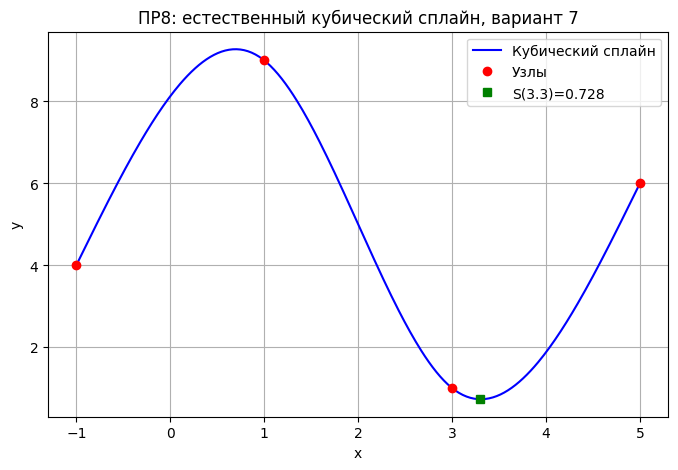

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Практическая работа №8
# Вариант 7
# Естественный кубический сплайн

x_nodes = np.array([-1, 1, 3, 5], dtype=float)
y_nodes = np.array([4, 9, 1, 6], dtype=float)
x_val = 3.3


def natural_cubic_spline(x, y):
    n = len(x) - 1
    h = np.diff(x)

    alpha = np.zeros(n + 1)
    for i in range(1, n):
        alpha[i] = 3/h[i] * (y[i+1] - y[i]) - 3/h[i-1] * (y[i] - y[i-1])

    l = np.ones(n + 1)
    mu = np.zeros(n + 1)
    z = np.zeros(n + 1)

    for i in range(1, n):
        l[i] = 2 * (x[i+1] - x[i-1]) - h[i-1] * mu[i-1]
        mu[i] = h[i] / l[i]
        z[i] = (alpha[i] - h[i-1] * z[i-1]) / l[i]

    a = y[:-1].copy()
    b = np.zeros(n)
    c = np.zeros(n + 1)
    d = np.zeros(n)

    for j in range(n - 1, -1, -1):
        c[j] = z[j] - mu[j] * c[j+1]
        b[j] = (y[j+1] - y[j]) / h[j] - h[j] * (c[j+1] + 2*c[j]) / 3
        d[j] = (c[j+1] - c[j]) / (3*h[j])

    return a, b, c[:-1], d


def spline_value(x_nodes, coeffs, x_val):
    a, b, c, d = coeffs
    i = np.searchsorted(x_nodes, x_val) - 1
    i = max(0, min(i, len(x_nodes) - 2))
    dx = x_val - x_nodes[i]
    return a[i] + b[i]*dx + c[i]*dx**2 + d[i]*dx**3


coeffs = natural_cubic_spline(x_nodes, y_nodes)
s_val = spline_value(x_nodes, coeffs, x_val)

print("Практическая работа №8, вариант 7")
print("Естественный кубический сплайн")
print(f"S({x_val}) = {s_val:.6f}")

print("\nКоэффициенты S_i(x)=a+b(x-x_i)+c(x-x_i)^2+d(x-x_i)^3:")
for i in range(len(x_nodes) - 1):
    print(
        f"[{x_nodes[i]:.0f}; {x_nodes[i+1]:.0f}]: "
        f"a={coeffs[0][i]:.6f}, b={coeffs[1][i]:.6f}, "
        f"c={coeffs[2][i]:.6f}, d={coeffs[3][i]:.6f}"
    )

# график
x_dense = np.linspace(x_nodes[0], x_nodes[-1], 300)
y_dense = [spline_value(x_nodes, coeffs, x) for x in x_dense]

plt.figure(figsize=(8, 5))
plt.plot(x_dense, y_dense, "b-", label="Кубический сплайн")
plt.plot(x_nodes, y_nodes, "ro", label="Узлы")
plt.plot(x_val, s_val, "gs", label=f"S({x_val})={s_val:.3f}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("ПР8: естественный кубический сплайн, вариант 7")
plt.legend()
plt.grid(True)
plt.savefig("pr8_spline_variant7.png", dpi=150)
plt.show()
plt.close()
